# OCR — locais de interesse + leitura

A carta já chegou recortada (CROPPER, 63×88 mm, P&B). Este notebook:

1. Treina um **YOLOv8 OBB** nas faixas `name` / `number` / `colection` (`OCR/data`).
2. Testa as caixas no split de teste.
3. Recorta cada faixa e lê o texto com **EasyOCR** (modelo pronto — não treinamos OCR do zero).

`colection` é o nome da classe no Roboflow (typo). Só existe quando a set está **escrita** na carta.

In [18]:
from __future__ import annotations

from pathlib import Path

VERSION = "v1"
EXPERIMENT_NAME = f"ocr-roi-{VERSION}"

ROOT = Path(".").resolve()
if not (ROOT / "train_ocr.ipynb").exists() and (ROOT / "OCR" / "train_ocr.ipynb").exists():
    ROOT = ROOT / "OCR"
REPO = ROOT.parent if ROOT.name == "OCR" else ROOT

DATASET_DIR = ROOT / "data"
DATA_YAML = DATASET_DIR / "data.yaml"
PROJECT_DIR = ROOT / "runs"


def bind_run_paths(run_dir: Path) -> None:
    global RUN_DIR, WEIGHTS_DIR
    RUN_DIR = Path(run_dir)
    WEIGHTS_DIR = RUN_DIR / "weights"


def find_existing_run_dir() -> Path | None:
    names = ("best.pt", f"{EXPERIMENT_NAME}.pt", "last.pt")
    candidates = [
        PROJECT_DIR / EXPERIMENT_NAME,
        PROJECT_DIR / "obb" / EXPERIMENT_NAME,
    ]
    for folder in candidates:
        weights = folder / "weights"
        if any((weights / name).exists() for name in names):
            return folder
    if PROJECT_DIR.exists():
        for name in names:
            for pt in PROJECT_DIR.rglob(name):
                if EXPERIMENT_NAME in pt.parts and pt.parent.name == "weights":
                    return pt.parent.parent
    return None


bind_run_paths(PROJECT_DIR / EXPERIMENT_NAME)
_existing = find_existing_run_dir()
if _existing:
    bind_run_paths(_existing)

PRETRAINED_MODEL = "yolov8n-obb.pt"
EPOCHS = 80
IMGSZ = 800
BATCH = 16
PATIENCE = 20
SEED = 42
WORKERS = 0
CONF = 0.4
MAX_SHOW = 8

LOSS = dict(box=7.5, dfl=1.5, angle=1.0)
AUGMENT = dict(
    degrees=8.0,
    flipud=0.0,
    fliplr=0.0,
    translate=0.04,
    scale=0.2,
    shear=0.0,
    hsv_h=0.0,
    hsv_s=0.2,
    hsv_v=0.2,
    mosaic=0.2,
    mixup=0.0,
    erasing=0.0,
    close_mosaic=10,
    cos_lr=True,
)

print(f"Experimento : {EXPERIMENT_NAME}")
print(f"Dataset     : {DATASET_DIR}  yaml={DATA_YAML.exists()}")
print(f"Saída       : {RUN_DIR}")
print(f"Modelo      : {PRETRAINED_MODEL} | epochs={EPOCHS} | imgsz={IMGSZ} | batch={BATCH}")


Experimento : ocr-roi-v1
Dataset     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\data  yaml=True
Saída       : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\runs\ocr-roi-v1
Modelo      : yolov8n-obb.pt | epochs=80 | imgsz=800 | batch=16


## 1. Ambiente

In [19]:
import subprocess
import sys

REQUIRED = {
    "ultralytics": "ultralytics",
    "pandas": "pandas",
    "pyyaml": "yaml",
    "matplotlib": "matplotlib",
    "opencv-python": "cv2",
    "pillow": "PIL",
}
missing = []
for pip_name, module_name in REQUIRED.items():
    try:
        __import__(module_name)
    except ImportError:
        missing.append(pip_name)
if missing:
    print(f"Instalando: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Dependências de treino ok.")

try:
    import easyocr  # noqa: F401
    print("EasyOCR ok.")
except ImportError:
    print("Instalando easyocr...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "easyocr"])


Dependências de treino ok.
EasyOCR ok.


In [20]:
from datetime import datetime
import platform

import pandas as pd
import torch
import ultralytics

print(pd.DataFrame([
    {"Item": "Data/hora", "Valor": datetime.now().strftime("%Y-%m-%d %H:%M:%S")},
    {"Item": "SO", "Valor": platform.platform()},
    {"Item": "Python", "Valor": platform.python_version()},
    {"Item": "PyTorch", "Valor": torch.__version__},
    {"Item": "Ultralytics", "Valor": ultralytics.__version__},
    {"Item": "CUDA", "Valor": torch.cuda.is_available()},
    {"Item": "GPU", "Valor": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "—"},
]).to_string(index=False))


       Item                     Valor
  Data/hora       2026-09-25 16:34:26
         SO Windows-11-10.0.26200-SP0
     Python                    3.14.7
    PyTorch              2.11.0+cu128
Ultralytics                   8.4.129
       CUDA                      True
        GPU   NVIDIA GeForce RTX 5060


## 2. Dataset (Roboflow em `OCR/data`)

In [21]:
import yaml
from collections import Counter

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"Exporte o YOLO OBB do Roboflow para {DATASET_DIR} (falta data.yaml)."
    )

cfg = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8"))
names = cfg.get("names") or {}
if isinstance(names, list):
    names = dict(enumerate(names))
print("classes:", names)

rows = []
cls_total = Counter()
for split in ("train", "valid", "test"):
    img_dir = DATASET_DIR / split / "images"
    lab_dir = DATASET_DIR / split / "labels"
    images = sorted(p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
    labels = list(lab_dir.glob("*.txt")) if lab_dir.exists() else []
    counts = Counter()
    empty = 0
    for lp in labels:
        text = lp.read_text(encoding="utf-8").strip()
        if not text:
            empty += 1
            continue
        for line in text.splitlines():
            cid = int(line.split()[0])
            counts[cid] += 1
            cls_total[cid] += 1
    rows.append({
        "split": split,
        "imagens": len(images),
        "labels": len(labels),
        "vazios": empty,
        **{names.get(i, str(i)): counts[i] for i in sorted(names)},
    })
print(pd.DataFrame(rows).to_string(index=False))
print("total por classe:", {names.get(k, k): v for k, v in sorted(cls_total.items())})


classes: {0: 'colection', 1: 'name', 2: 'number'}
split  imagens  labels  vazios  colection  name  number
train      205     205       0        137   205     205
valid       59      59       0         33    58      58
 test       29      29       0         20    29      29
total por classe: {'colection': 190, 'name': 292, 'number': 292}


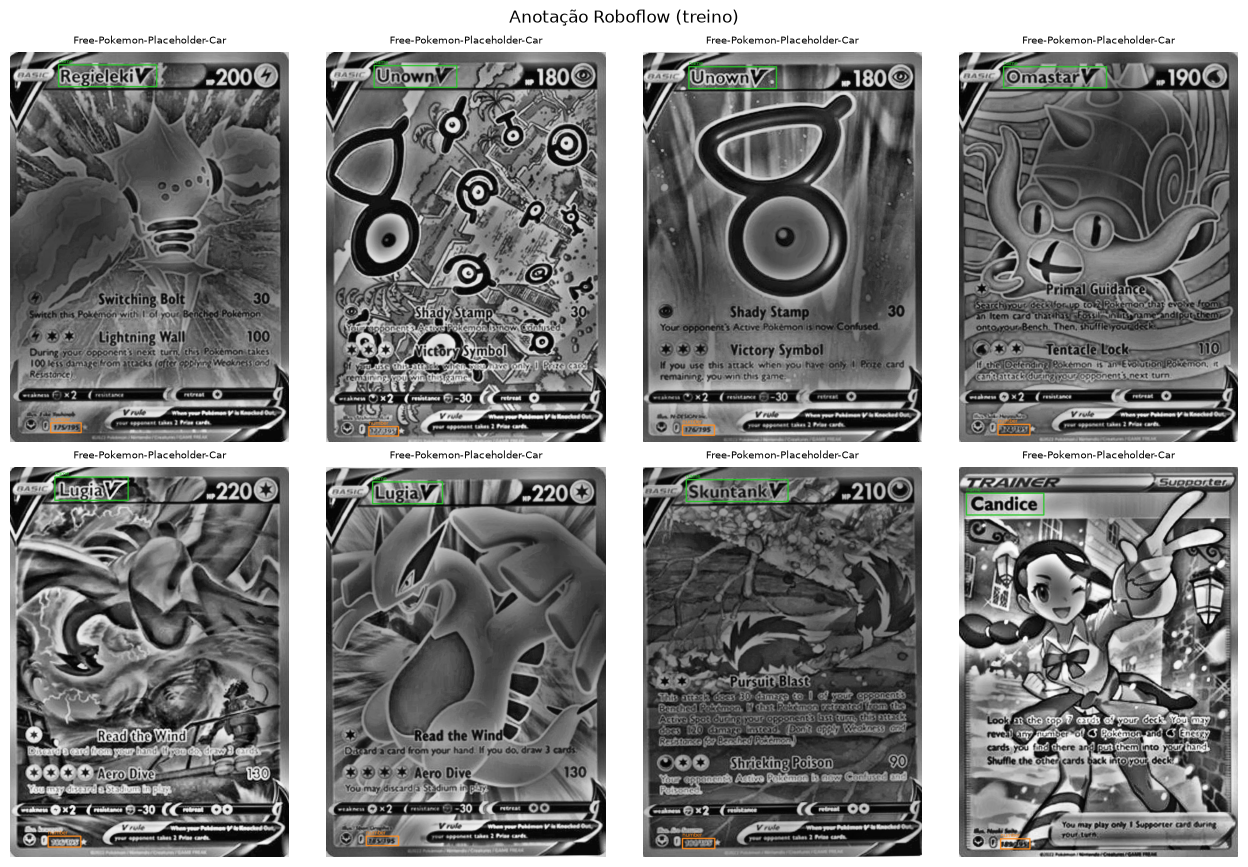

In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

COLORS = {0: (40, 180, 255), 1: (40, 200, 40), 2: (30, 140, 255)}


def draw_obb_label(bgr: np.ndarray, label_path: Path, names: dict) -> np.ndarray:
    vis = bgr.copy()
    h, w = vis.shape[:2]
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return vis
    for line in text.splitlines():
        parts = line.split()
        cid = int(parts[0])
        coords = np.array([float(x) for x in parts[1:]], dtype=np.float32)
        if coords.size == 8:
            pts = coords.reshape(4, 2)
            pts[:, 0] *= w
            pts[:, 1] *= h
        else:
            cx, cy, bw, bh = coords[:4]
            x0, y0 = (cx - bw / 2) * w, (cy - bh / 2) * h
            x1, y1 = (cx + bw / 2) * w, (cy + bh / 2) * h
            pts = np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=np.float32)
        color = COLORS.get(cid, (200, 200, 200))
        cv2.polylines(vis, [pts.astype(np.int32)], True, color, 2, cv2.LINE_AA)
        x, y = int(pts[:, 0].min()), int(pts[:, 1].min())
        cv2.putText(vis, names.get(cid, str(cid)), (x, max(14, y - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return vis


train_imgs = sorted((DATASET_DIR / "train" / "images").glob("*.jpg"))[:MAX_SHOW]
cols = min(4, max(1, len(train_imgs)))
rows_n = int(np.ceil(len(train_imgs) / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 4.4 * rows_n))
axes = np.atleast_1d(axes).ravel()
for ax, img_path in zip(axes, train_imgs):
    bgr = cv2.imread(str(img_path))
    lab = DATASET_DIR / "train" / "labels" / (img_path.stem + ".txt")
    vis = draw_obb_label(bgr, lab, names) if lab.exists() else bgr
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name[:28], fontsize=7)
    ax.axis("off")
for ax in axes[len(train_imgs):]:
    ax.axis("off")
fig.suptitle("Anotação Roboflow (treino)")
plt.tight_layout()
plt.show()


## 3. Treinar YOLO OBB (locais de interesse)

Altere `VERSION` e rode. Se já existir `ocr-roi-v1.pt`, a célula seguinte só carrega.

In [23]:
from ultralytics import YOLO

final_pt = WEIGHTS_DIR / f"{EXPERIMENT_NAME}.pt"
best_pt = WEIGHTS_DIR / "best.pt"
if final_pt.exists() or best_pt.exists():
    print(f"Já treinado: {final_pt if final_pt.exists() else best_pt}")
    print("Apague a pasta do run se quiser retreinar.")
else:
    model = YOLO(PRETRAINED_MODEL)
    results = model.train(
        data=str(DATA_YAML.resolve()),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        patience=PATIENCE,
        seed=SEED,
        workers=WORKERS,
        project=str(PROJECT_DIR),
        name=EXPERIMENT_NAME,
        exist_ok=True,
        device=0 if torch.cuda.is_available() else "cpu",
        **LOSS,
        **AUGMENT,
    )
    bind_run_paths(Path(results.save_dir))
    print(f"Treino em {RUN_DIR}")


New https://pypi.org/project/ultralytics/8.4.163 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.129  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8150MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\data\data.yaml, degrees=8.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.2, hsv_v=0.2, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lr

## 4. Validar e copiar pesos

In [24]:
from shutil import copy2

_existing = find_existing_run_dir()
if _existing:
    bind_run_paths(_existing)

best_pt = WEIGHTS_DIR / "best.pt"
named_pt = WEIGHTS_DIR / f"{EXPERIMENT_NAME}.pt"
if best_pt.exists() and not named_pt.exists():
    copy2(best_pt, named_pt)
WEIGHTS = named_pt if named_pt.exists() else best_pt
if not WEIGHTS.exists():
    raise FileNotFoundError(f"Treine antes. Faltando: {WEIGHTS_DIR}")

roi_model = YOLO(str(WEIGHTS))
val = roi_model.val(
    data=str(DATA_YAML.resolve()),
    split="val",
    imgsz=IMGSZ,
    batch=BATCH,
    workers=WORKERS,
    device=0 if torch.cuda.is_available() else "cpu",
    plots=True,
)
print(f"Pesos : {WEIGHTS}")
metrics = getattr(val, "obb", None) or getattr(val, "box", None)
if metrics is not None:
    print(f"mAP50 : {float(metrics.map50):.3f}   mAP50-95: {float(metrics.map):.3f}")
else:
    print(getattr(val, "results_dict", val))


Ultralytics 8.4.129  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8150MiB)
YOLOv8n-obb summary (fused): 82 layers, 3,077,804 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1493.2135.3 MB/s, size: 157.3 KB)
val: Scanning C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\data\valid\labels.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 22.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.3it/s 1.2s0.5s
                   all         59        149      0.975      0.973      0.978      0.795
             colection         32         33      0.981       0.97      0.965      0.812
                  name         58         58      0.961          1      0.984      0.776
                number         58         58      0.982       0.95      0.986      0.797
Speed: 0.4ms preprocess, 3.3ms inference, 0.0ms loss, 2.5ms postprocess

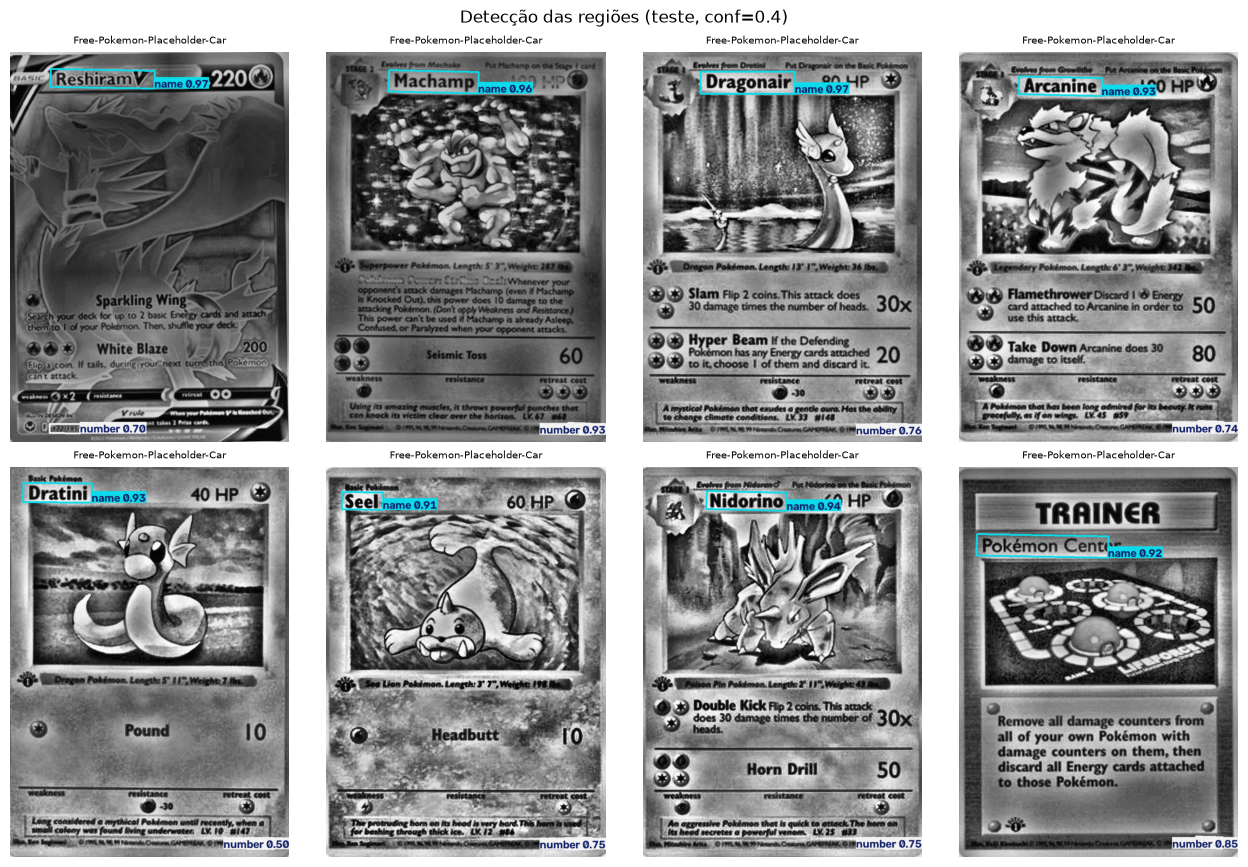

In [25]:
test_dir = DATASET_DIR / "test" / "images"
test_imgs = sorted(p for p in test_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
show = test_imgs[:MAX_SHOW]
if not show:
    raise FileNotFoundError(test_dir)

preds = roi_model.predict(
    source=[str(p) for p in show],
    conf=CONF,
    imgsz=IMGSZ,
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=False,
)

cols = min(4, len(show))
rows_n = int(np.ceil(len(show) / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 4.4 * rows_n))
axes = np.atleast_1d(axes).ravel()
for ax, result in zip(axes, preds):
    vis = result.plot()
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(Path(result.path).name[:28], fontsize=7)
    ax.axis("off")
for ax in axes[len(show):]:
    ax.axis("off")
fig.suptitle(f"Detecção das regiões (teste, conf={CONF})")
plt.tight_layout()
plt.show()


## 5. OCR nas faixas detectadas

EasyOCR lê **só** `name`, `number` e `collection` (esta última só se o detector achar caixa).

In [26]:
import sys

sys.path.insert(0, str(ROOT))
from read_card import read_card

import easyocr

reader = easyocr.Reader(["en", "pt"], gpu=torch.cuda.is_available())
print("EasyOCR carregado.")


EasyOCR carregado.


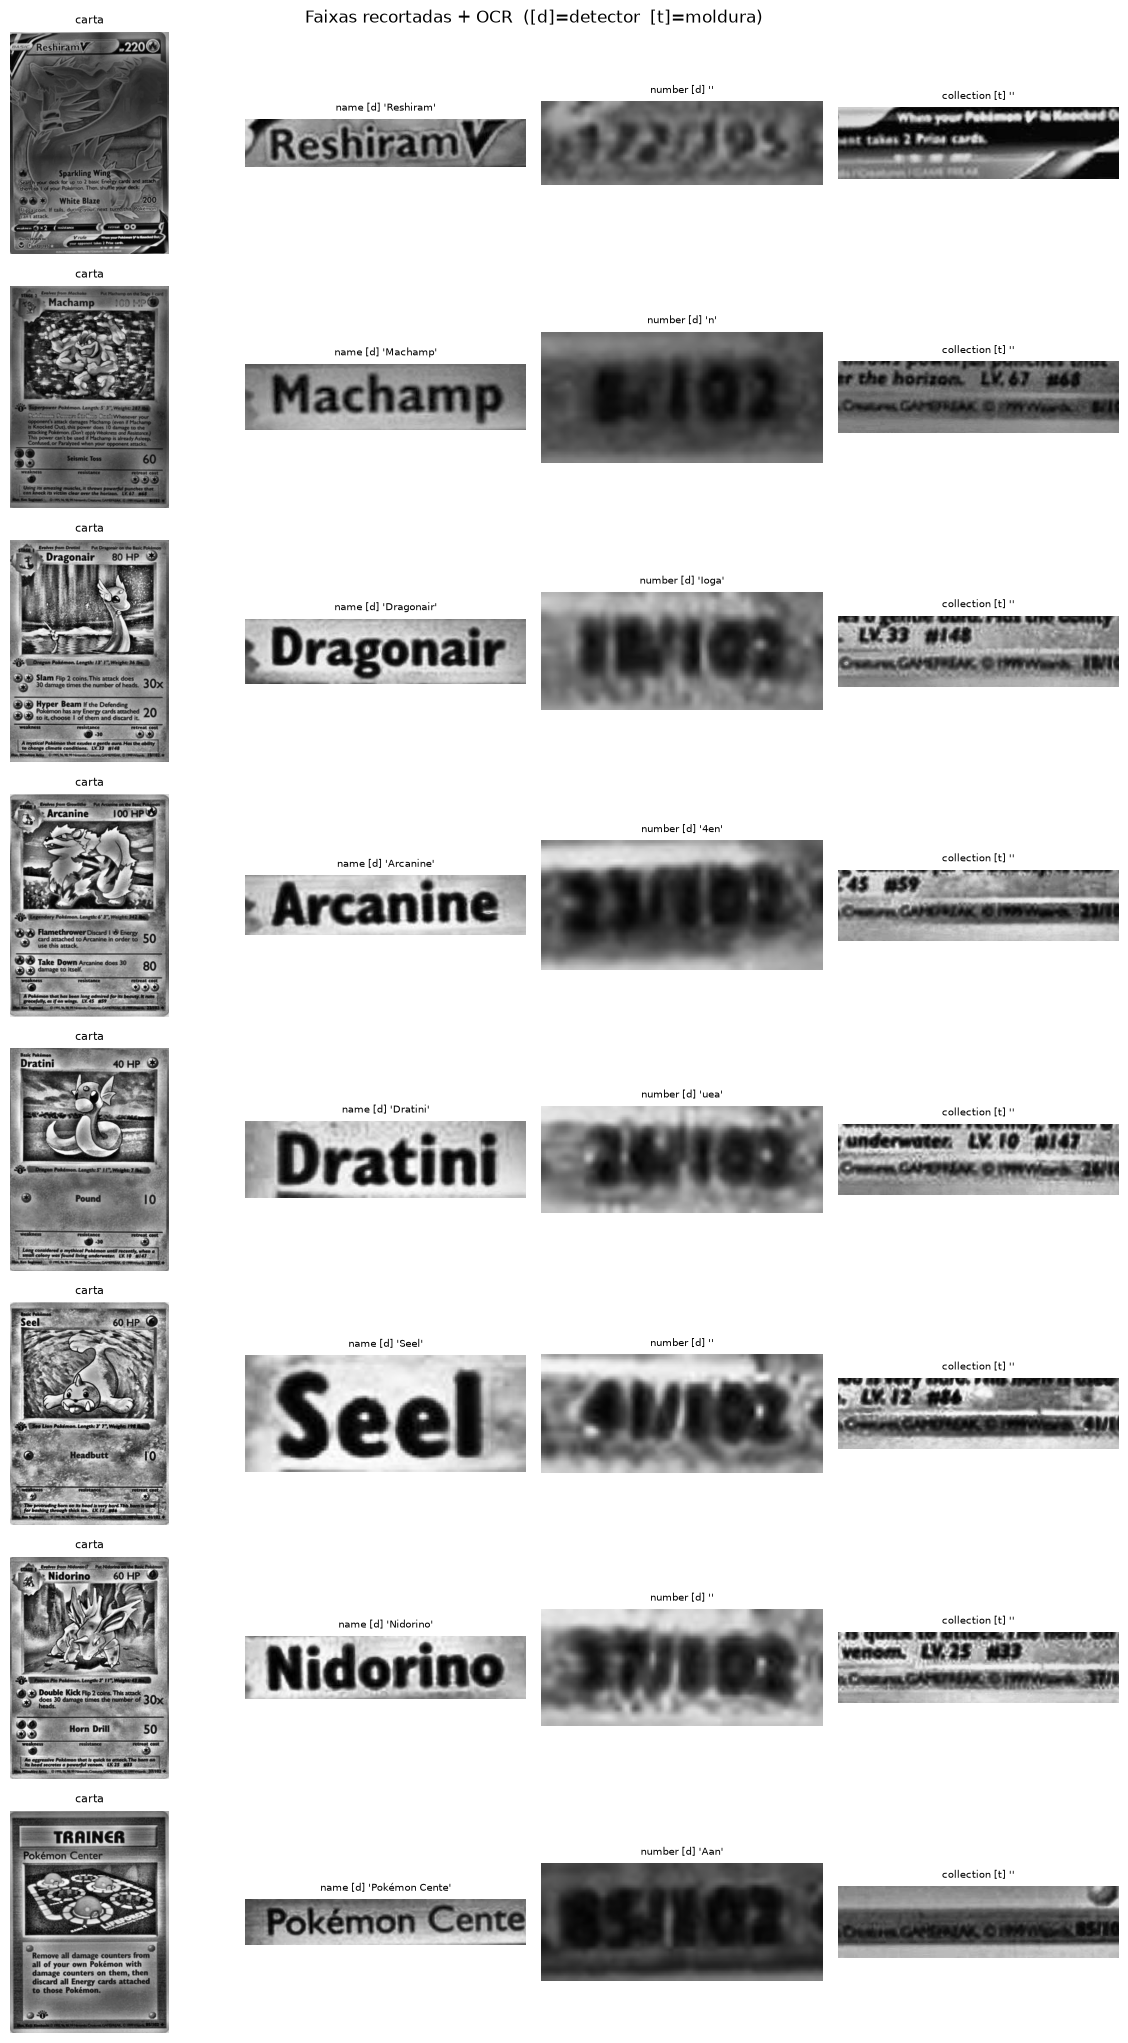

                                 arquivo          name number collection
Free-Pokemon-Placeholder-Card-Generator-      Reshiram                  
Free-Pokemon-Placeholder-Card-Generator-       Machamp      n           
Free-Pokemon-Placeholder-Card-Generator-     Dragonair   Ioga           
Free-Pokemon-Placeholder-Card-Generator-      Arcanine    4en           
Free-Pokemon-Placeholder-Card-Generator-       Dratini    uea           
Free-Pokemon-Placeholder-Card-Generator-          Seel                  
Free-Pokemon-Placeholder-Card-Generator-      Nidorino                  
Free-Pokemon-Placeholder-Card-Generator- Pokémon Cente    Aan           


In [27]:
ocr_rows = []
n_show = min(MAX_SHOW, len(preds))
fig, axes = plt.subplots(n_show, 4, figsize=(12, 2.6 * n_show))
if n_show == 1:
    axes = np.array([axes])

for i, result in enumerate(preds[:n_show]):
    card = read_card(result, reader, conf_min=CONF)
    ocr_rows.append({
        "arquivo": Path(result.path).name[:40],
        "name": card.name,
        "number": card.number,
        "collection": card.collection,
    })
    full = result.orig_img
    axes[i, 0].imshow(cv2.cvtColor(full, cv2.COLOR_BGR2RGB) if full.ndim == 3 else full, cmap="gray")
    axes[i, 0].set_title("carta", fontsize=8)
    for j, field in enumerate(("name", "number", "collection"), start=1):
        region = card.regions[field]
        img = region.image
        if img.ndim == 3:
            axes[i, j].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            axes[i, j].imshow(img, cmap="gray")
        tag = region.source[0]
        axes[i, j].set_title(f"{field} [{tag}] {region.text[:18]!r}", fontsize=7)
    for ax in axes[i]:
        ax.axis("off")

fig.suptitle("Faixas recortadas + OCR  ([d]=detector  [t]=moldura)")
plt.tight_layout()
plt.show()
print(pd.DataFrame(ocr_rows).to_string(index=False))


## 6. Teste no split inteiro (tabela)

In [28]:
all_preds = roi_model.predict(
    source=str(test_dir),
    conf=CONF,
    imgsz=IMGSZ,
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=False,
)
table = []
for result in all_preds:
    card = read_card(result, reader, conf_min=CONF)
    table.append({
        "arquivo": Path(result.path).stem[:48],
        "name": card.name,
        "number": card.number,
        "collection": card.collection,
        "name_src": card.regions["name"].source,
        "number_src": card.regions["number"].source,
        "collection_src": card.regions["collection"].source,
    })
df = pd.DataFrame(table)
out_csv = ROOT / "runs" / f"{EXPERIMENT_NAME}_ocr_test.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_csv, index=False, encoding="utf-8")
print(df.to_string(index=False))
print(f"\nCSV: {out_csv}")


                                         arquivo               name  number collection name_src number_src collection_src
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi           Reshiram                         det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi            Machamp       n                 det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi          Dragonair    oice                 det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi           Arcanine     4en                 det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi            Dratini    Juea                 det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi               Seel                         det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi           Nidorino                         det        det       template
Free-Pokemon-Placeholder